<a href="https://colab.research.google.com/github/AnzorGozalishvili/IOAI-2025-lectures/blob/main/lecture_31_transformers_finetuning_on_classification/notebooks/Davit6174_georgian_distilbert_mlm_%26_Arseniy_Sandalov_Georgian_Sentiment_Analysis_Sentiment_Analysis_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Davit6174/georgian-distilbert-mlm
- Model Card: https://huggingface.co/Davit6174/georgian-distilbert-mlm
- Sentiment Dataset Source: https://data.jrc.ec.europa.eu/dataset/9f04066a-8cc0-4669-99b4-f1f0627fdbbf
- dataset on huggingface: https://huggingface.co/datasets/Arseniy-Sandalov/Georgian-Sentiment-Analysis

### class label map
- https://huggingface.co/Arseniy-Sandalov/GeorgianBert-Sent/blob/main/config.json

```json
{
  "0": "Mixed",
  "1": "Positive",
  "2": "Neutral",
  "3": "Negative"
}
```

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
from transformers import pipeline

# Load the tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("Davit6174/georgian-distilbert-mlm")
# Load the PyTorch model instead of the TensorFlow model
model = AutoModelForMaskedLM.from_pretrained("Davit6174/georgian-distilbert-mlm", from_tf=True)

# Build pipeline
mask_filler = pipeline(
    "fill-mask", model=model, tokenizer=tokenizer
)

text = 'ქართული <mask> [MASK] სწავლა საკმაოდ რთულია'

# Generate model output
preds = mask_filler(text)

# Print top 5 predictions
for pred in preds:
    print(f">>> {pred['sequence']}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/526k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/998k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/524 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

All TF 2.0 model weights were used when initializing DistilBertForMaskedLM.

Some weights of DistilBertForMaskedLM were not initialized from the TF 2.0 model and are newly initialized: ['vocab_projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


>>> ქართული < mask > ქართული სწავლა საკმაოდ რთულია
>>> ქართული < mask > - სწავლა საკმაოდ რთულია
>>> ქართული < mask > > სწავლა საკმაოდ რთულია
>>> ქართული < mask >, სწავლა საკმაოდ რთულია
>>> ქართული < mask > სწავლა სწავლა საკმაოდ რთულია


# Prepare Model For Sentiment Classification

In [ ]:
from transformers import AutoModelForSequenceClassification

# Load the sequence classification model
num_labels = 4 # Binary classification (positive/negative)
model = AutoModelForSequenceClassification.from_pretrained("Davit6174/georgian-distilbert-mlm", num_labels=num_labels, from_tf=True)


All TF 2.0 model weights were used when initializing DistilBertForSequenceClassification.

All the weights of DistilBertForSequenceClassification were initialized from the TF 2.0 model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use DistilBertForSequenceClassification for predictions without further training.


# Load Sentiment Dataset

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 13.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [ ]:
from datasets import load_dataset
import pandas as pd

CLASSES = ['Mixed', 'Positive', 'Neutral', 'Negative']

dataset = load_dataset("Arseniy-Sandalov/Georgian-Sentiment-Analysis")
pd.Series(dataset['train']['sentiment']).value_counts()

README.md:   0%|          | 0.00/2.33k [00:00<?, ?B/s]

Dataset.csv:   0%|          | 0.00/1.37M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4219 [00:00<?, ? examples/s]

,count
Neutral,1731
Negative,1417
Positive,765
Mixed,306


## Create Dataset Splits (check class distributions)

We use 80:10:10 splitting portions: https://huggingface.co/Arseniy-Sandalov/GeorgianBert-Sent#%F0%9F%93%8A-training-details

In [ ]:
from datasets import DatasetDict

# Assuming 'dataset' is your loaded dataset from the previous code
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
dataset['validation'] = dataset.pop('test')
dataset['test'] = dataset['validation'].train_test_split(test_size=0.5, seed=42)['test']
dataset = DatasetDict(dataset)

# Verify the splits
print(dataset)
print(dataset['train'].features)
print(dataset['validation'].features)
print(dataset['test'].features)

# Check class distributions after splitting
print(pd.Series(dataset['train']['sentiment']).value_counts())
print(pd.Series(dataset['validation']['sentiment']).value_counts())
print(pd.Series(dataset['test']['sentiment']).value_counts())


DatasetDict({
    train: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 3375
    })
    validation: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 844
    })
    test: Dataset({
        features: ['text', 'sentiment', 'perturbation'],
        num_rows: 422
    })
})
{'text': Value(dtype='string', id=None), 'sentiment': Value(dtype='string', id=None), 'perturbation': Value(dtype='float64', id=None)}
{'text': Value(dtype='string', id=None), 'sentiment': Value(dtype='string', id=None), 'perturbation': Value(dtype='float64', id=None)}
{'text': Value(dtype='string', id=None), 'sentiment': Value(dtype='string', id=None), 'perturbation': Value(dtype='float64', id=None)}
Neutral     1374
Negative    1137
Positive     617
Mixed        247
Name: count, dtype: int64
Neutral     357
Negative    280
Positive    148
Mixed        59
Name: count, dtype: int64
Neutral     189
Negative    141
Positive     65
Mixed        27
Name

# Train

In [14]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score, accuracy_score

# Define training arguments
training_args = TrainingArguments(
    # output_dir="./sentiment_classification_results",  # Output directory
    output_dir=None,
    evaluation_strategy="epoch",  # Evaluate at the end of each epoch
    learning_rate=2e-5,  # Learning rate
    per_device_train_batch_size=32,  # Batch size per device during training
    per_device_eval_batch_size=64,  # Batch size for evaluation
    num_train_epochs=10,  # Number of training epochs
    weight_decay=0.01,  # Weight decay
    push_to_hub=False,  # Whether to upload the model to the Hugging Face Model Hub
    # logging_dir='./logs',
    logging_dir=None,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    # Align save_strategy with evaluation_strategy
    save_strategy="epoch",
    report_to="none",
)

# Function to tokenize the dataset
def tokenize_function(examples):
    examples['labels'] = [CLASSES.index(label) for label in examples["sentiment"]]
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Tokenize the dataset
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Function to compute metrics
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro')
    return {"accuracy": acc, "f1": f1}

# Create Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],  # Use the tokenized training dataset
    eval_dataset=tokenized_datasets["validation"],  # Use the tokenized validation dataset
    tokenizer=tokenizer,
    compute_metrics=compute_metrics, # Pass the compute_metrics function

)

# Train the model
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-14-3356abd223bd>:42: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.602900,1.074299,0.619668,0.503667
2,0.504200,1.162018,0.579384,0.481149
3,0.450600,1.200409,0.603081,0.513144
4,0.268500,1.432933,0.562796,0.447201


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.602900,1.074299,0.619668,0.503667
2,0.504200,1.162018,0.579384,0.481149
3,0.450600,1.200409,0.603081,0.513144
4,0.268500,1.432933,0.562796,0.447201
5,0.273800,1.384317,0.598341,0.513008
6,0.166500,1.465869,0.600711,0.520342
7,0.116500,1.654931,0.585308,0.502204
8,0.114000,1.686577,0.588863,0.510814
9,0.067300,1.780922,0.582938,0.511393
10,0.035800,1.768835,0.588863,0.506155


TrainOutput(global_step=1060, training_loss=0.2512162080069758, metrics={'train_runtime': 1731.8298, 'train_samples_per_second': 19.488, 'train_steps_per_second': 0.612, 'total_flos': 4470934164480000.0, 'train_loss': 0.2512162080069758, 'epoch': 10.0})

# Explain Model Predictions

In [15]:
!pip install transformers-interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/5

In [16]:
from transformers_interpret import SequenceClassificationExplainer

cls_explainer = SequenceClassificationExplainer(model, tokenizer)

In [20]:
def interpret_text(text):
  word_attributions = cls_explainer(text)
  return cls_explainer.visualize()


for text, sentiment in zip(tokenized_datasets['test']['text'][:10], tokenized_datasets['test']['labels'][:10]):
    interpret_text(text)
    print(sentiment)

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
2,LABEL_2 (0.99),LABEL_2,2.46,"[CLS] ნუ ##გზარ წიკლაური ამბობს , რომ პოლიტიკური შეხედულებები ##ს მიუხედავად , მაინც დაეს ##წრება სხდომას , რადგან საკითხი მნიშვნელოვანია [SEP]"


2


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
3,LABEL_3 (0.96),LABEL_3,3.12,[CLS] დიდი ოდენობით ნარკოტიკული საშუალების უკანონო შეძენა - შენახვის ##ა და გასაღები ##ს ბრალდებით ორი მამაკაცი დააკავეს [SEP]


2


3


...

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
2,LABEL_2 (0.94),LABEL_2,1.45,"[CLS] დავით ზალკალი ##ანის განმარტებით , მუდმივად მიმდინარეობს საუბარი იმ საკითხებზე , რაც ეხება ამერიკელები ##ს დახმარებით საქართველოს გაძლიერებას [SEP]"


1


3


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
2,LABEL_2 (0.56),LABEL_2,1.26,"[CLS] დავით ნარმანი ##ას თქმით , ყველა ჯარიმა , რომელიც სტიქიის ადგილზე იქნა გამო ##წერი ##ლი იქნება გაუქმ ##ებული [SEP]"


1


## Evaluate

In [26]:
from torch.utils.data import DataLoader, TensorDataset
import torch

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

label_to_id = {k:idx for idx,k in enumerate(CLASSES)}
id_to_label = {idx:k for idx,k in enumerate(CLASSES)}

def create_dataloader(dataset, tokenizer, batch_size=32, max_length=512):
    texts = [example['text'] for example in dataset]
    label_ids = [example['labels'] for example in dataset]  # Assuming 'label' key exists
    labels = [id_to_label[label_id] for label_id in label_ids]

    # Tokenize the texts
    encoded_inputs = tokenizer(texts, truncation=True, padding='max_length', max_length=max_length, return_tensors='pt')

    # Create TensorDataset
    dataset = TensorDataset(encoded_inputs['input_ids'], encoded_inputs['attention_mask'], torch.tensor(label_ids))

    # Create DataLoader
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False) # Set shuffle=False for inference

    return dataloader


# Example Usage
batch_size = 256  # Adjust as needed
train_dataloader = create_dataloader(tokenized_datasets['train'], tokenizer, batch_size=batch_size) # Use 'train' split
val_dataloader = create_dataloader(tokenized_datasets['validation'], tokenizer, batch_size=batch_size) # Use 'validation' split
test_dataloader = create_dataloader(tokenized_datasets['test'], tokenizer, batch_size=batch_size) # Use 'test' split

In [27]:
next(iter(train_dataloader)),next(iter(val_dataloader)), next(iter(test_dataloader))

([tensor([[   2,  467, 3952,  ...,    0,    0,    0],
          [   2,  421, 9417,  ...,    0,    0,    0],
          [   2,  389, 2307,  ...,    0,    0,    0],
          ...,
          [   2, 4555, 1108,  ...,    0,    0,    0],
          [   2,  925,  665,  ...,    0,    0,    0],
          [   2, 6019,  655,  ...,    0,    0,    0]]),
  tensor([[1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          ...,
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0],
          [1, 1, 1,  ..., 0, 0, 0]]),
  tensor([2, 3, 3, 1, 2, 3, 2, 0, 1, 3, 2, 0, 3, 2, 0, 0, 3, 3, 2, 2, 3, 3, 3, 1,
          1, 3, 3, 3, 3, 3, 1, 3, 2, 1, 1, 3, 3, 3, 2, 3, 2, 3, 1, 0, 2, 3, 2, 2,
          0, 3, 2, 2, 1, 2, 2, 3, 1, 3, 2, 2, 2, 3, 3, 3, 2, 3, 1, 3, 2, 3, 1, 1,
          2, 2, 1, 2, 2, 1, 2, 3, 2, 2, 2, 3, 2, 3, 3, 1, 2, 2, 3, 2, 3, 2, 3, 2,
          3, 1, 2, 3, 1, 2, 0, 3, 3, 3, 2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 0,
          2, 2, 

In [28]:
def predict_batch(batch, model):
    model.eval()
    input_ids, attention_mask, labels = batch
    with torch.no_grad():
        # Move inputs to the device
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = outputs.logits.argmax(dim=1).cpu().tolist()
        probabilities = outputs.logits.softmax(dim=1).cpu().tolist()
        labels = labels.tolist()

    return predictions, probabilities, labels

batch_preds, batch_probs, batch_labels = predict_batch(batch=next(iter(val_dataloader)), model=model)
print(batch_preds[:10], batch_probs[:10], batch_labels[:10])

[1, 3, 1, 3, 1, 2, 3, 0, 2, 2] [[0.006568583194166422, 0.9798582792282104, 0.012619048357009888, 0.0009540726896375418], [0.009170180186629295, 0.0019082081271335483, 0.14399288594722748, 0.8449287414550781], [0.003666409058496356, 0.9915939569473267, 0.0041839550249278545, 0.0005557143595069647], [0.05558720976114273, 0.008830335922539234, 0.009194456972181797, 0.9263879656791687], [0.0051778824999928474, 0.9890840649604797, 0.0049898577854037285, 0.0007481432403437793], [0.029770681634545326, 0.0025582846719771624, 0.9299190044403076, 0.037752024829387665], [0.4555351138114929, 0.03779517486691475, 0.04358970746397972, 0.46307995915412903], [0.5883431434631348, 0.0367233008146286, 0.3051430284976959, 0.06979048997163773], [0.004112158436328173, 0.0014257754664868116, 0.992159366607666, 0.0023027453571558], [0.005758658051490784, 0.0018119142623618245, 0.9452281594276428, 0.047201287001371384]] [0, 2, 1, 3, 1, 2, 1, 0, 2, 3]


In [29]:
from tqdm import tqdm

def batch_predict_sentiment(dataloader, model):
    all_predictions = []
    all_probabilities = []
    all_labels = []

    for batch in tqdm(dataloader):
        predictions, probabilities, labels = predict_batch(batch, model)

        all_predictions.extend(predictions)
        all_labels.extend(labels)
        all_probabilities.extend(probabilities)

    return all_predictions, all_probabilities, all_labels

train_predictions, train_probabilities, train_labels = batch_predict_sentiment(train_dataloader, model)
val_predictions, val_probabilities, val_labels = batch_predict_sentiment(val_dataloader, model)
test_predictions, test_probabilities, test_labels = batch_predict_sentiment(test_dataloader, model)

100%|██████████| 2/2 [00:12<00:00,  6.12s/it]


              precision    recall  f1-score   support

       Mixed       0.96      0.88      0.92       247
    Positive       1.00      0.98      0.99       617
     Neutral       0.99      0.99      0.99      1374
    Negative       0.98      1.00      0.99      1137

    accuracy                           0.99      3375
   macro avg       0.98      0.96      0.97      3375
weighted avg       0.99      0.99      0.99      3375



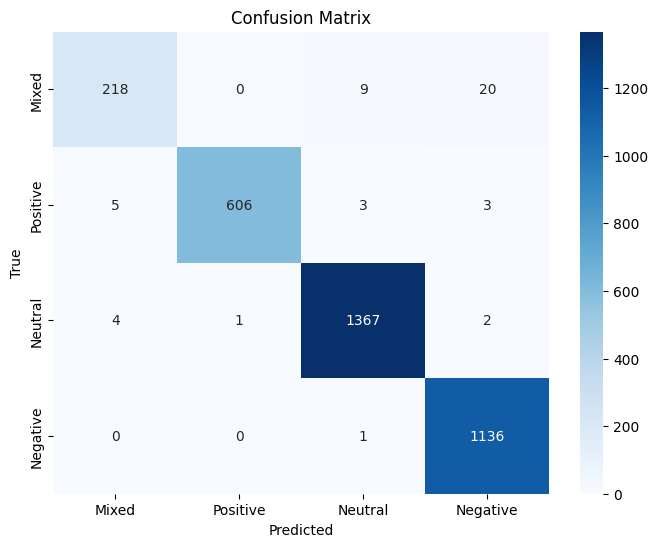

Macro F1-Score: 0.9728627379215609
AUC-ROC (OVO, macro): 0.9984715839476468
              precision    recall  f1-score   support

       Mixed       0.22      0.22      0.22        59
    Positive       0.64      0.55      0.59       148
     Neutral       0.68      0.64      0.66       357
    Negative       0.57      0.65      0.61       280

    accuracy                           0.60       844
   macro avg       0.53      0.52      0.52       844
weighted avg       0.60      0.60      0.60       844



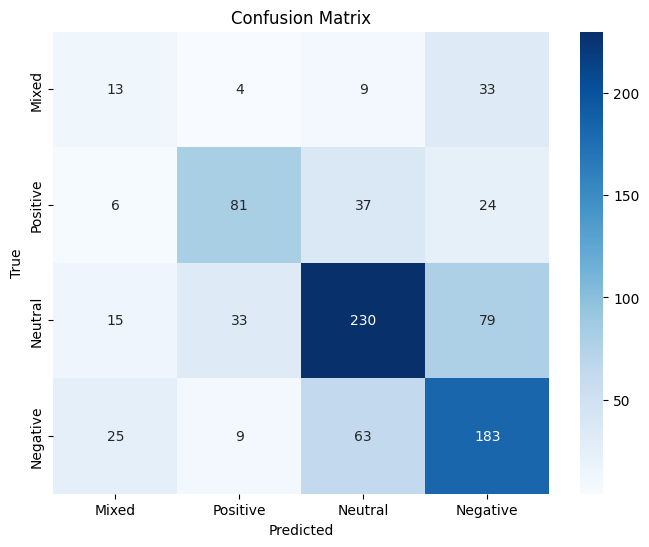

Macro F1-Score: 0.5203419490778853
AUC-ROC (OVO, macro): 0.7910533113013923
              precision    recall  f1-score   support

       Mixed       0.25      0.30      0.27        27
    Positive       0.57      0.54      0.56        65
     Neutral       0.68      0.62      0.65       189
    Negative       0.58      0.65      0.61       141

    accuracy                           0.59       422
   macro avg       0.52      0.52      0.52       422
weighted avg       0.60      0.59      0.60       422



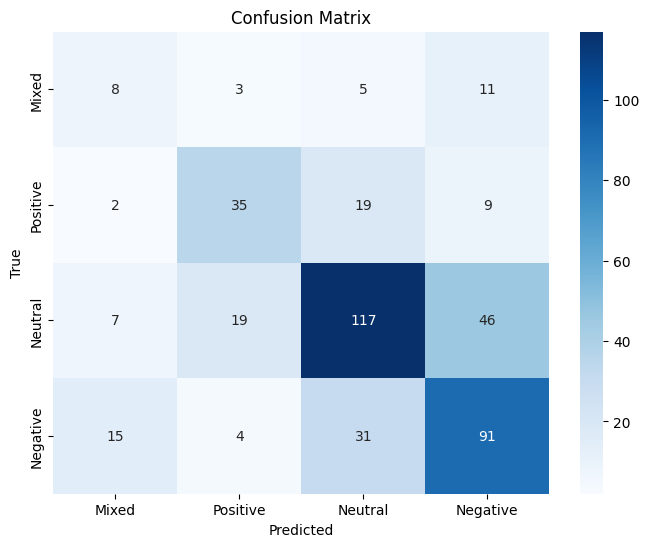

Macro F1-Score: 0.5214199243126145
AUC-ROC (OVO, macro): 0.7977888209180497


In [30]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def classification_reports(true_labels, predicted_labels, predicted_probabilities):

    # Classification Report
    print(classification_report(true_labels, predicted_labels, target_names=CLASSES))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES,
                yticklabels=CLASSES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # F1-Score (macro average)
    f1 = f1_score(true_labels, predicted_labels, average='macro')
    print(f"Macro F1-Score: {f1}")


    # AUC-ROC (requires probabilities)
    try:
        auc_roc = roc_auc_score(np.eye(4)[true_labels], np.array(predicted_probabilities), multi_class='ovo', average='macro')
        print(f"AUC-ROC (OVO, macro): {auc_roc}")
    except ValueError as e:
        print(f"AUC-ROC Calculation failed: {e}")

classification_reports(true_labels=train_labels, predicted_labels=train_predictions, predicted_probabilities=train_probabilities)
classification_reports(true_labels=val_labels, predicted_labels=val_predictions, predicted_probabilities=val_probabilities)
classification_reports(true_labels=test_labels, predicted_labels=test_predictions, predicted_probabilities=test_probabilities)